# 空间点在相机中的投影

In [8]:
%matplotlib tk

**导入相关的模块**

In [1]:
import numpy as np
import math
from spatialmath import SE3
from spatialmath.base import e2h, h2e
from roboticstoolbox import *

**通过改进DH参数法，对机械臂上相机进行定义**

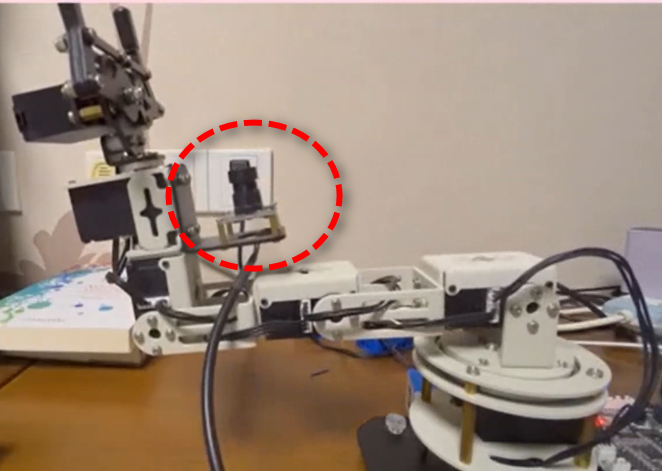

In [3]:
DFbot = DHRobot(
    [                 
                    RevoluteMDH(d=0.04145,qlim=np.array([-np.pi,np.pi])),            
                    RevoluteMDH(alpha=np.pi/2,qlim=np.array([-np.pi,np.pi])),
                    RevoluteMDH(a=-0.08285,qlim=np.array([-np.pi,np.pi])),
                    RevoluteMDH(a=-0.08285,qlim=np.array([-np.pi,np.pi])),
                    RevoluteMDH(alpha=-np.pi/2,qlim=np.array([0,np.pi])),
                    RevoluteMDH(a=0.05,d=0.06,qlim=np.array([-np.pi,np.pi]))
                  
    ],
    name="DFbot",
)

In [10]:
DFbot.plot([0,0,0,0,0,0],block=False)

<IPython.core.display.Javascript object>

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'DFbot')

**通过相机标定获取的内参矩阵**

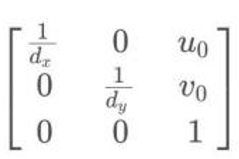

u0,v0为相机的中心点

In [25]:
mtx=np.array([[919.21981864,   0.        , 356.41270451],
       [  0.        , 913.16565134, 236.9305    ],
       [  0.        ,   0.        ,   1.        ]])

In [26]:
#投影矩阵

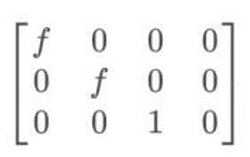

In [27]:
P0 = np.array([ [1, 0, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 1, 0]])

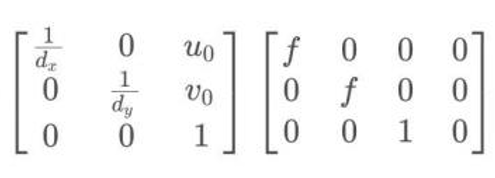

In [28]:
K=mtx@P0

In [59]:
#位姿矩阵

**改变相机姿态，让摄像头指向桌面，获取相机矩阵**

In [29]:
T1=DFbot.fkine([np.pi/2,-np.pi/6,0,np.pi,0,0])
T1

   0        -1         0         0         
  -0.866     0        -0.5      -0.2168    
   0.5       0        -0.866     0.09734   
   0         0         0         1         


In [30]:
DFbot.plot([np.pi/2,-np.pi/6,0,np.pi,0,0])

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'DFbot')

**指定需要投影到相机中的点**

In [31]:
P= np.array([0, -0.28, 0])

**转换成齐次矩阵**

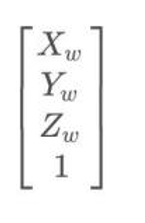

In [33]:
P1=e2h(P)
P1

array([[ 0.  ],
       [-0.28],
       [ 0.  ],
       [ 1.  ]])

**获取外参矩阵，外参矩阵为相机矩阵的逆矩阵**

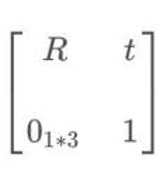

In [35]:
extrinsic = np.linalg.inv(T1)
extrinsic

array([[-8.36449319e-17, -8.66025404e-01,  5.00000000e-01,
        -2.36425000e-01],
       [-1.00000000e+00,  3.06161700e-17, -1.14261102e-16,
         4.73612267e-18],
       [ 8.36449319e-17, -5.00000000e-01, -8.66025404e-01,
        -2.41032470e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

获取P3d

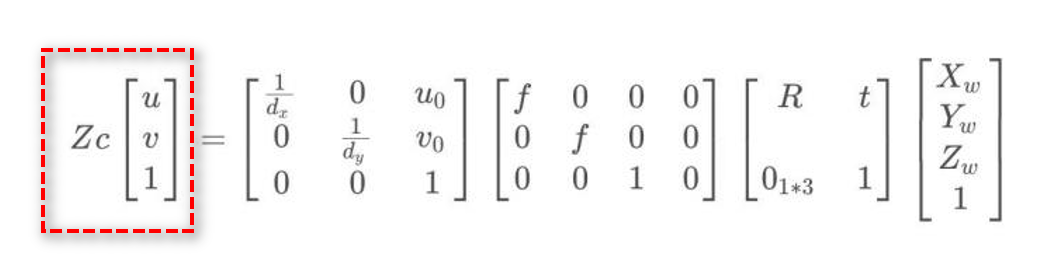

In [36]:
P3d=K@extrinsic@P1

In [37]:
P3d

array([[46.87948964],
       [27.45947563],
       [ 0.11589675]])

**归1化**

In [18]:
P3d/P3d[-1]

array([[404.49355513],
       [236.9305    ],
       [  1.        ]])

**比对U,V是否符合定义的点在相机中的投影关系**

## 课程内容：
1、变换定义的点，获取相机中的投影坐标；

2、根据例程，当相机不在机械臂上，在外部固定时，如何获取空间点在相机中的投影坐标。